In [4]:
from datetime import datetime, date
import matplotlib.pyplot as plt
import numpy as np

import sklearn.linear_model
import sklearn.model_selection
import pandas as pd
import yfinance as yfin

In [5]:
start = datetime(2023, 1, 5)
end = datetime.today()

df_aapl = yfin.download("AAPL", start, end)
df_fb = yfin.download("META", start, end)
df_gold = yfin.download("GLD", start, end)
df_aapl.tail()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-01-16,255.529999,258.899994,254.929993,257.899994,72142800
2026-01-20,246.699997,254.789993,243.419998,252.729996,80267500
2026-01-21,247.649994,251.559998,245.179993,248.699997,54641700
2026-01-22,248.350006,251.000000,248.149994,249.199997,39708300
2026-01-23,248.039993,249.410004,244.679993,247.320007,41625700


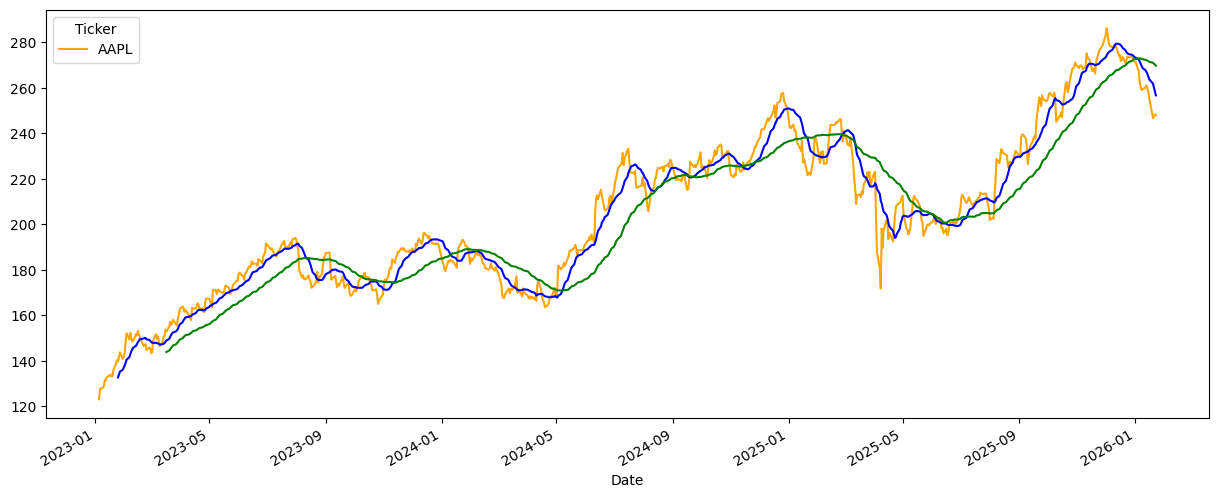

In [6]:
df_aapl['SMA'] = df_aapl['Close'].rolling(window=14).mean()
df_aapl['SMA50'] = df_aapl['Close'].rolling(window=50).mean()
df_aapl['Close'].plot(figsize=(15,6), color="orange")
df_aapl['SMA'].plot(figsize=(15,6), color="blue")
df_aapl['SMA50'].plot(figsize=(15,6), color='green')
plt.show()


In [7]:
df_aapl['change'] = (((df_aapl['Close'] - df_aapl['Open'])) / (df_aapl['Open']) * 100)
df_fb['change'] = (((df_fb['Close'] - df_fb['Open'])) / (df_fb['Open']) * 100)
df_gold['change'] = (((df_gold['Close'] - df_gold['Open'])) / (df_gold['Open']) * 100)

df_aapl.tail(5).round(2)

Price,Close,High,Low,Open,Volume,SMA,SMA50,change
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2026-01-16,255.53,258.90,254.93,257.90,72142800,263.79,271.49,-0.92
2026-01-20,246.70,254.79,243.42,252.73,80267500,261.86,271.03,-2.39
2026-01-21,247.65,251.56,245.18,248.70,54641700,260.04,270.59,-0.42
2026-01-22,248.35,251.00,248.15,249.20,39708300,258.36,270.20,-0.34
2026-01-23,248.04,249.41,244.68,247.32,41625700,256.72,269.77,0.29


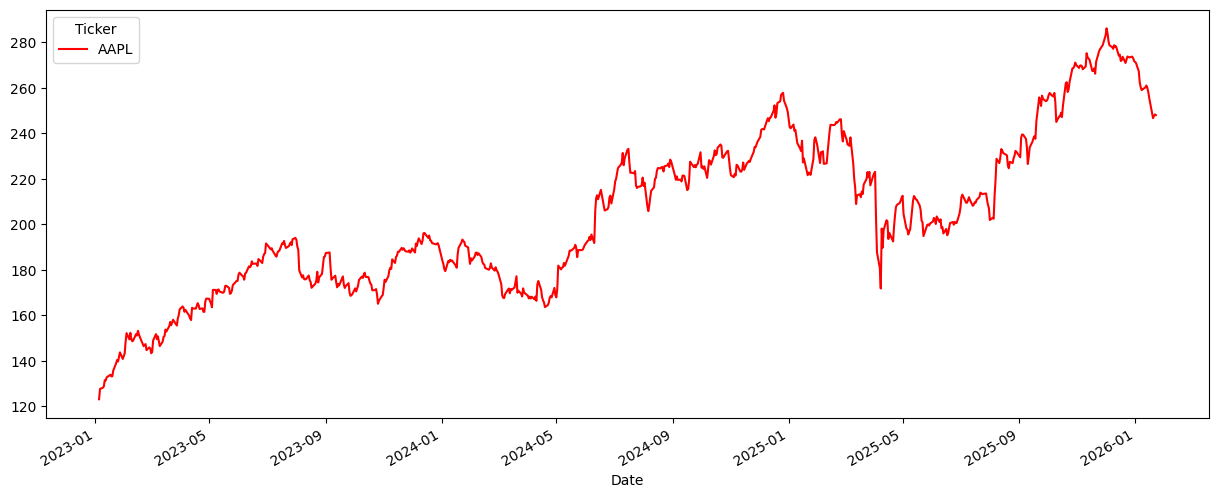

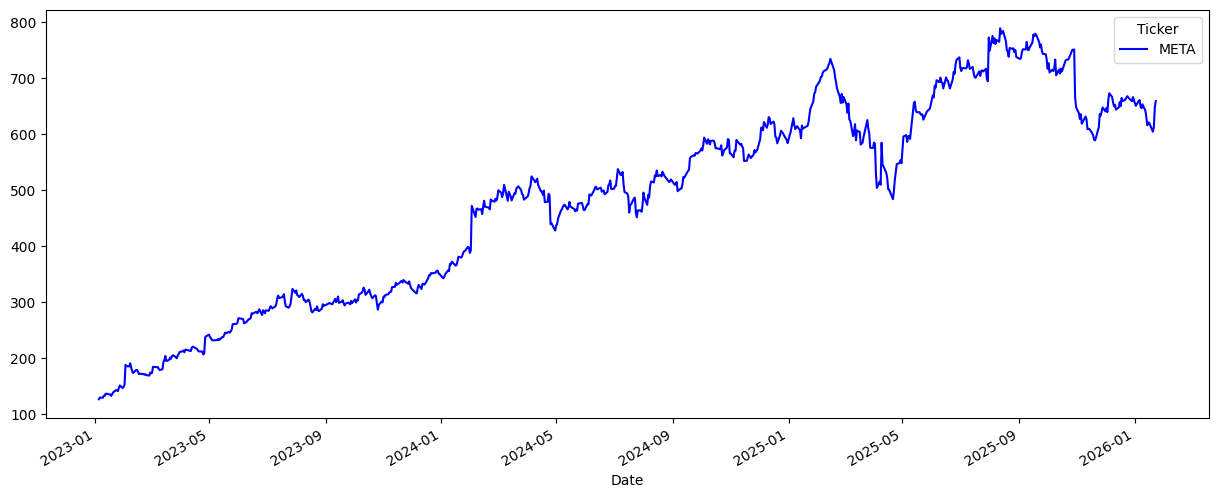

In [8]:
df_aapl['Close'].plot(figsize=(15,6), color="red")
df_fb['Close'].plot(figsize=(15,6), color="blue")
plt.show()

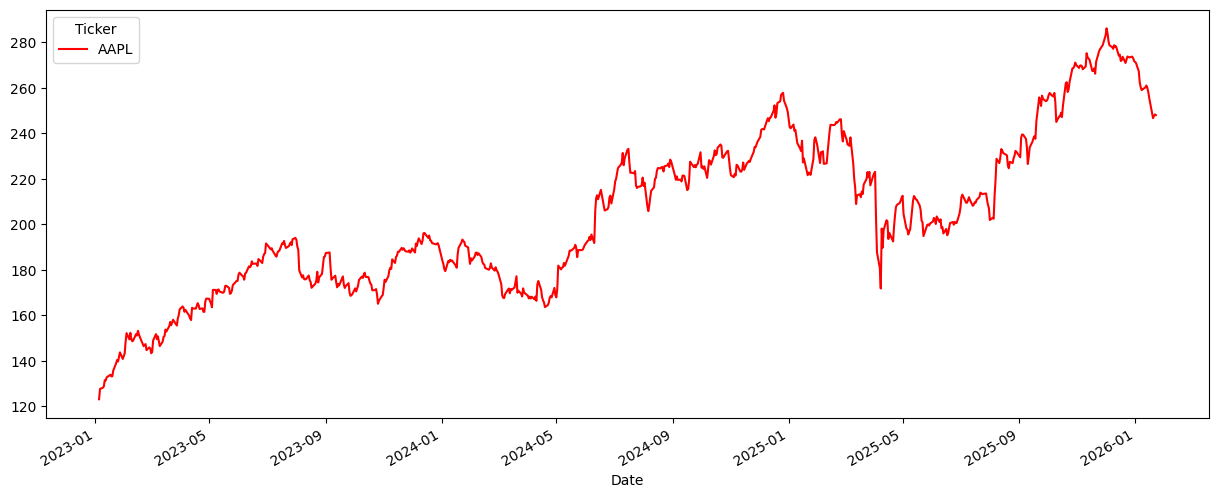

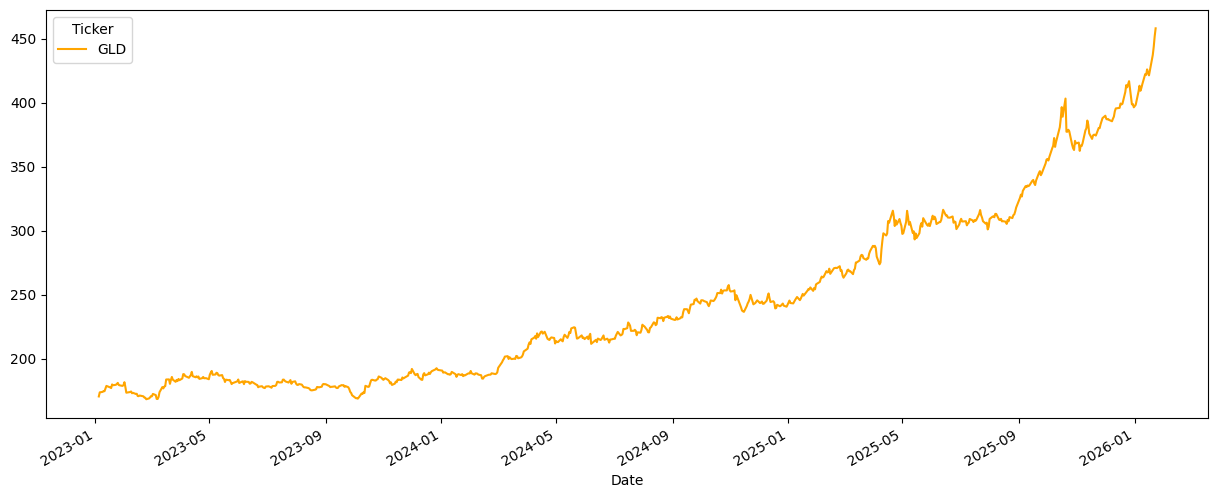

In [9]:
df_aapl['Close'].plot(figsize=(15,6), color="red")
df_gold['Close'].plot(figsize=(15,6), color="orange")
plt.show()

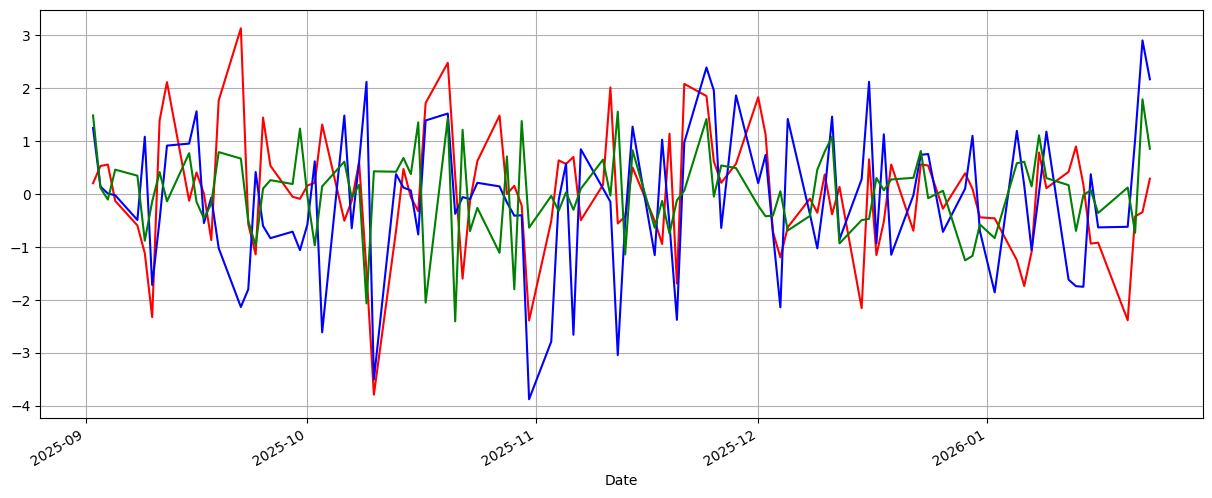

In [10]:
df_aapl['change'].tail(100).plot(grid=True, figsize=(15,6), color="red")
df_fb['change'].tail(100).plot(grid=True, figsize=(15,6), color="blue")
df_gold['change'].tail(100).plot(grid=True, figsize=(15,6), color="green")
plt.show()

In [11]:
df_aapl['label'] = df_aapl['Close'].shift(-30)
df_aapl.tail(35)

Price,Close,High,Low,Open,Volume,SMA,SMA50,change,label
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2025-12-03,284.149994,288.619995,283.299988,286.200012,43538700,274.949286,264.422160,-0.716289,255.529999
2025-12-04,280.700012,284.730011,278.589996,284.100006,43989100,275.502858,264.994847,-1.196760,246.699997
2025-12-05,278.779999,281.140015,278.049988,280.540009,47265800,275.957857,265.438023,-0.627365,247.649994
2025-12-08,277.890015,279.670013,276.149994,278.130005,38211800,276.702859,265.891571,-0.086287,248.350006
2025-12-09,277.179993,280.029999,276.920013,278.160004,32193300,277.398573,266.351499,-0.352319,248.039993
2025-12-10,278.779999,279.750000,276.440002,277.750000,33038300,278.128573,266.839431,0.370837,NaN
2025-12-11,278.029999,279.589996,273.809998,279.100006,33248000,278.970001,267.295979,-0.383378,NaN
2025-12-12,278.279999,279.220001,276.820007,277.899994,39532900,279.455002,267.723959,0.136742,NaN


In [12]:
X = np.array(df_aapl.drop(['label', 'SMA'], axis=1))
X = sklearn.preprocessing.scale(X)

In [13]:
predict_data = X[-30:]

In [14]:
X = X[:-30]

In [15]:
y = np.array(df_aapl['label'])
y = y[:-30]

In [20]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.2)
model = sklearn.linear_model.LinearRegression()
model.fit(X_train,y_train)

accuracy = model.score(X_test, y_test)
accuracy

NameError: name 'sklearn' is not defined

In [21]:
predicted_data = model.predict(predict_data)
predicted_data

NameError: name 'model' is not defined

In [15]:
df_aapl['Predict'] = np.nan
df_aapl.tail(35)

NameError: name 'np' is not defined

In [16]:
last_date = df_aapl.iloc[-1].name

NameError: name 'df_aapl' is not defined

In [17]:
one_day = 86400
next_unix = last_date.timestamp() + one_day

NameError: name 'last_date' is not defined

In [22]:
df_aapl.tail(35)

NameError: name 'df_aapl' is not defined

In [23]:
df_aapl['Close'].plot(figsize=(15,6),color="green")
df_aapl['Predict'].plot(figsize=(15,6), color="orange")
plt.show()

NameError: name 'df_aapl' is not defined